In [1]:
!nvidia-smi

Tue Apr 21 11:33:32 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro RTX 8000                On  | 00000000:3B:00.0 Off |                  Off |
| 68%   82C    P2              86W / 260W |  39848MiB / 49152MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Quadro RTX 8000


Setup & GPU Check

In [3]:

!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.30.0 \
                sentence-transformers==3.0.1 fairlearn==0.10.0 \
                indic-nlp-library snorkel==0.9.9 optuna wandb evaluate



In [4]:
import os, torch, random, numpy as np, pandas as pd
from datetime import datetime
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"CUDA Version: {torch.version.cuda}")

 Device: cuda | GPU: Quadro RTX 8000
CUDA Version: 12.1


/home/chhamman/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Enable GPU optimization
torch.backends.cudnn.benchmark = True

Using: cuda


Install Dependencies

In [6]:
import subprocess, sys

packages = [
    'transformers==4.40.0',
    'datasets==2.19.0',
    'accelerate>=0.30.0',
    'sentence-transformers==2.7.0',
    'scikit-learn>=1.3.0',
    'pandas>=2.0.0',
    'numpy>=1.24.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'tqdm',
    'evaluate',
    'sentencepiece',
    'protobuf',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed!')


All packages installed!


Imports & Configuration

In [7]:
import os, re, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
from typing import List, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset, load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)

warnings.filterwarnings('ignore')

#  Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#  Device 
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = torch.cuda.is_available()
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

#  Paths 
BASE_DIR   = Path('.')
DATA_DIR   = BASE_DIR / 'data'
MODEL_DIR  = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'
for d in [DATA_DIR, MODEL_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#  Config  (optimized for Quadro RTX 8000 — 49 GB VRAM) 
CFG = {
    'main_model'   : 'xlm-roberta-large',   # large fits easily in 49 GB
    'weak_model'   : 'paraphrase-multilingual-MiniLM-L12-v2',
    'max_len'      : 256,
    'batch_size'   : 8,     # big batch — 49 GB VRAM
    'num_epochs'   : 8,
    'lr'           : 1e-5,
    'warmup_ratio' : 0.10,
    'weight_decay' : 0.01,
    'grad_accum'   : 1,      # no accumulation needed with large batch
    'fp16'         : USE_FP16,
    'ws_threshold' : 0.70,
    'pseudo_pool'  : 800,
    'parity_target': 0.03,
}

print('\n Config ready')
print(f'   Model      : {CFG["main_model"]}')
print(f'   Batch size : {CFG["batch_size"]}')
print(f'   Epochs     : {CFG["num_epochs"]}')
print(f'   FP16       : {CFG["fp16"]}')

I0000 00:00:1776751453.035788 3211638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776751453.088683 3211638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776751454.261907 3211638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Device : cuda
GPU    : Quadro RTX 8000
VRAM   : 51.0 GB

 Config ready
   Model      : xlm-roberta-large
   Batch size : 8
   Epochs     : 8
   FP16       : True


In [8]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi'] = 400
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.figsize'] = (6,5)

Data Loading 

In [9]:
!git clone https://github.com/Exploration-Lab/CJPE.git

fatal: destination path 'CJPE' already exists and is not an empty directory.


In [10]:
!rm -rf CJPE
!git clone https://github.com/Exploration-Lab/CJPE.git

Cloning into 'CJPE'...
remote: Enumerating objects: 847, done.
remote: Counting objects: 100% (427/427), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 847 (delta 190), reused 374 (delta 159), pack-reused 420 (from 1)
Receiving objects: 100% (847/847), 13.15 MiB | 5.97 MiB/s, done.
Resolving deltas: 100% (470/470), done.


In [11]:

from datasets import load_dataset, Dataset
import pandas as pd
import os
import random

print("Loading expert labeled dataset (IndianBailJudgments-1200)...")
expert_ds = load_dataset("SnehaDeshmukh/IndianBailJudgments-1200", split="train")
expert_df = expert_ds.to_pandas()[['facts', 'bail_outcome']].dropna()
expert_df['label'] = expert_df['bail_outcome'].str.lower().apply(lambda x: 1 if 'grant' in x else 0)
expert_df = expert_df[['facts', 'label']].rename(columns={'facts': 'text'})

print(f"Expert labeled samples: {len(expert_df)}")

# SYNTHETIC GENERATOR 
class SyntheticBailDataGenerator:
    GRANTED_TEMPLATES = [
        "The bail application filed by the accused/applicant is hereby GRANTED. The applicant shall be released on bail subject to furnishing surety bonds of Rs. {amount}.",
        "After hearing learned counsel, this court is of the considered opinion that the bail application deserves to be allowed.",
        "जमानत प्रार्थनापत्र पर विचार करने के पश्चात न्यायालय का यह मत है कि आवेदक को जमानत पर रिहा किया जाए।"
    ]
    DENIED_TEMPLATES = [
        "The bail application is hereby REJECTED/DISMISSED.",
        "After careful consideration, the bail application is dismissed.",
        "जमानत प्रार्थनापत्र अस्वीकार किया जाता है।"
    ]
    IPC_SECTIONS = ['302', '307', '376', '420', '498A']

    def generate(self, n_samples=6000):
        records = []
        for i in range(n_samples):
            label = random.choice([0, 1])
            templates = self.GRANTED_TEMPLATES if label == 1 else self.DENIED_TEMPLATES
            text = random.choice(templates).format(
                amount=random.choice([10000, 25000, 50000, 100000]),
                section=random.choice(self.IPC_SECTIONS)
            )
            records.append({'text': text, 'label': label})
        return pd.DataFrame(records)

# UNLABELED POOL (Synthetic ) 
print("Generating synthetic unlabeled data...")
gen = SyntheticBailDataGenerator()
synthetic_df = gen.generate(6000)

# Handle CJPE clone safely
if not os.path.exists("CJPE"):
    print(" Cloning CJPE (ILDC) repository...")
    !git clone -q https://github.com/Exploration-Lab/CJPE.git
else:
    print("CJPE folder already exists → using local copy")

# Load ILDC locally from cloned repo 
ildc_df = pd.DataFrame(columns=['text'])
ildc_paths = [
    "CJPE/Data/ILDC_single/train.json",
    "CJPE/ILDC/train.json",
    "CJPE/data/ILDC_single.json",
    "CJPE/ILDC_single.json"
]

for path in ildc_paths:
    if os.path.exists(path):
        print(f" Loading ILDC from local file: {path}")
        try:
            ildc_local = load_dataset("json", data_files=path, split="train")
            ildc_df = ildc_local.to_pandas()[['text']].dropna().sample(3000, random_state=42)
            break
        except:
            continue

if len(ildc_df) == 0:
    print("Could not load ILDC locally → using extra synthetic data")
    extra_synthetic = gen.generate(3000)
    ildc_df = extra_synthetic[['text']].copy()

ildc_df['label'] = -1  # mark as unlabeled

# Final unlabeled pool
unlabeled_df = pd.concat([synthetic_df, ildc_df], ignore_index=True)
unlabeled_ds = Dataset.from_pandas(unlabeled_df[['text']])

print(f"Total Unlabeled pool: {len(unlabeled_df)} samples (Synthetic + ILDC)")
print(f"Expert: {len(expert_df)} | Unlabeled pool: {len(unlabeled_ds)}")

Loading expert labeled dataset (IndianBailJudgments-1200)...


Expert labeled samples: 1200
Generating synthetic unlabeled data...
CJPE folder already exists → using local copy
Could not load ILDC locally → using extra synthetic data
Total Unlabeled pool: 9000 samples (Synthetic + ILDC)
Expert: 1200 | Unlabeled pool: 9000


Contextualized Weak Supervision

In [12]:
from sentence_transformers import SentenceTransformer, util
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

print("Weak Supervision Running...")

# Better model
ws_model = SentenceTransformer('all-mpnet-base-v2')


SEED_GRANTED = [
    "bail granted",
    "released on bail",
    "bail allowed",
    "enlarged on bail",
    "जमानत मंजूर",
    "जमानत स्वीकृत"
]

SEED_DENIED = [
    "bail rejected",
    "bail denied",
    "bail dismissed",
    "application rejected",
    "जमानत खारिज"
]

def generate_pseudo_labels(texts):

    granted_emb = ws_model.encode(SEED_GRANTED, convert_to_tensor=True)
    denied_emb  = ws_model.encode(SEED_DENIED, convert_to_tensor=True)

    labels = []
    margins = []
    final_texts = []

    for text in tqdm(texts):

        text = str(text)

      
        text = text[:500] + text[-500:]

        emb = ws_model.encode(text, convert_to_tensor=True)

        sim_g = util.cos_sim(emb, granted_emb).max().item()
        sim_d = util.cos_sim(emb, denied_emb).max().item()

        margin = sim_g - sim_d

        if margin > 0.02:
            label = 1
        elif margin < -0.02:
            label = 0
        else:
            continue   # skip weak samples

        labels.append(label)
        margins.append(margin)
        final_texts.append(text)

    return final_texts, labels, margins



texts, labels, margins = generate_pseudo_labels(unlabeled_ds["text"])

pseudo_df = pd.DataFrame({
    "text": texts,
    "label": labels,
    "margin": margins
})


print("\n BEFORE FILTER:")
print("Granted:", sum(pseudo_df["label"] == 1))
print("Denied:", sum(pseudo_df["label"] == 0))


# TOP-K 

pseudo_df["confidence"] = np.abs(pseudo_df["margin"])

grant_df = pseudo_df[pseudo_df.label == 1].sort_values("confidence", ascending=False)
deny_df  = pseudo_df[pseudo_df.label == 0].sort_values("confidence", ascending=False)

top_k_g = int(0.3 * len(grant_df))
top_k_d = int(0.3 * len(deny_df))

grant_df = grant_df.head(top_k_g)
deny_df  = deny_df.head(top_k_d)

high_conf = pd.concat([grant_df, deny_df]).reset_index(drop=True)

print("After class-wise Top-K:")
print("Granted:", len(grant_df))
print("Denied:", len(deny_df))
print("Total:", len(high_conf))


# BALANCE 
grant_df = high_conf[high_conf.label == 1]
deny_df = high_conf[high_conf.label == 0]

print("Before balance:", len(grant_df), len(deny_df))

if len(grant_df) == 0 or len(deny_df) == 0:
    print(" One class only — skipping balance")
    balanced_df = high_conf
else:
    min_size = min(len(grant_df), len(deny_df))
    grant_df = grant_df.sample(min_size, random_state=42)
    deny_df = deny_df.sample(min_size, random_state=42)
    balanced_df = pd.concat([grant_df, deny_df])

print("Balanced size:", len(balanced_df))


combined_df = pd.concat([expert_df, balanced_df[["text", "label"]]])
combined_df = combined_df.sample(frac=1).reset_index(drop=True)

print("\n FINAL DATASET:", len(combined_df))

Weak Supervision Running...


  1%|          | 52/9000 [00:01<03:09, 47.24it/s]

100%|██████████| 9000/9000 [03:12<00:00, 46.78it/s]


 BEFORE FILTER:
Granted: 3053
Denied: 3039
After class-wise Top-K:
Granted: 915
Denied: 911
Total: 1826
Before balance: 915 911
Balanced size: 1822

 FINAL DATASET: 3022


Combined Dataset + Train/Val/Test Split

In [13]:
from sklearn.model_selection import train_test_split

# Step 1: Train + Temp split
train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.2,          # 80% train
    stratify=combined_df["label"],
    random_state=42
)

# Step 2: Val + Test split
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # 10% val, 10% test
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 2417
Val: 302
Test: 303


In [14]:
print("Train:", len(train_df))

Train: 2417


TEXT + LABEL LIST

In [15]:
train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = val_df["text"].tolist()
val_labels = val_df["label"].tolist()

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

TOKENIZATION

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512
    )

train_enc = tokenize(train_texts)
val_enc   = tokenize(val_texts)
test_enc  = tokenize(test_texts)

DATASET CLASS

In [17]:
import torch

class BailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BailDataset(train_enc, train_labels)
val_dataset   = BailDataset(val_enc, val_labels)
test_dataset  = BailDataset(test_enc, test_labels)

BASELINE MODELS

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

vectorizer = TfidfVectorizer(max_features=10000)

X_train = vectorizer.fit_transform(train_df["text"])
X_test  = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test  = test_df["label"]

results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

results["LR"] = {
    "acc": accuracy_score(y_test, pred_lr),
    "f1": f1_score(y_test, pred_lr)
}

# SVM
svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

results["SVM"] = {
    "acc": accuracy_score(y_test, pred_svm),
    "f1": f1_score(y_test, pred_svm)
}

MODEL LOAD (xlm-roberta)

In [19]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

model.to("cuda")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768,

METRICS

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

TRAINING

In [21]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7,
    evaluation_strategy="epoch",
    # save_strategy="epoch",
    # logging_dir="./logs",
    fp16=True,
    report_to="none"
    # load_best_model_at_end=True
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.606710,0.824503,0.861619,0.756881,1.000000


TrainOutput(global_step=1064, training_loss=0.15908481180667877, metrics={'train_runtime': 232.1694, 'train_samples_per_second': 72.874, 'train_steps_per_second': 4.583, 'total_flos': 1304172640323000.0, 'train_loss': 0.15908481180667877, 'epoch': 7.0})

VALIDATION RESULT

In [22]:
val_results = trainer.evaluate()
print("Validation:", val_results)

Validation: {'eval_loss': 0.5317145586013794, 'eval_accuracy': 0.9039735099337748, 'eval_f1': 0.9113149847094801, 'eval_precision': 0.9197530864197531, 'eval_recall': 0.9030303030303031, 'eval_runtime': 0.8124, 'eval_samples_per_second': 371.734, 'eval_steps_per_second': 23.387, 'epoch': 7.0}


TEST RESULT

In [23]:
test_results = trainer.evaluate(test_dataset)
print("Test:", test_results)

Test: {'eval_loss': 0.5318873524665833, 'eval_accuracy': 0.8976897689768977, 'eval_f1': 0.9057750759878419, 'eval_precision': 0.9085365853658537, 'eval_recall': 0.9030303030303031, 'eval_runtime': 0.887, 'eval_samples_per_second': 341.597, 'eval_steps_per_second': 21.42, 'epoch': 7.0}


In [24]:
# model.save_pretrained("final_model")
tokenizer.save_pretrained("final_model")

('final_model/tokenizer_config.json',
 'final_model/special_tokens_map.json',
 'final_model/sentencepiece.bpe.model',
 'final_model/added_tokens.json',
 'final_model/tokenizer.json')

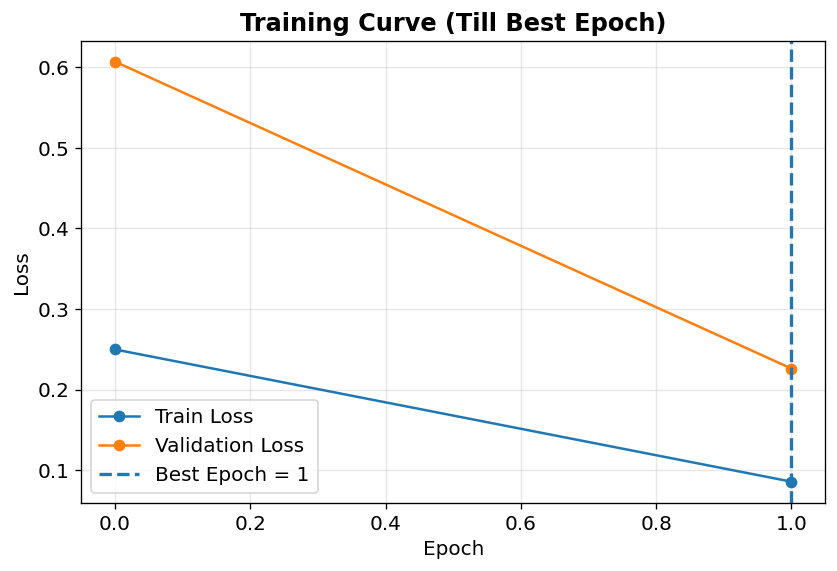

Best Epoch: 1
Best Validation Loss: 0.2260


In [25]:
logs = trainer.state.log_history

# Extract losses
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss  = [x["eval_loss"] for x in logs if "eval_loss" in x]

import matplotlib.pyplot as plt

# --- Find best epoch (minimum validation loss) ---
best_epoch = eval_loss.index(min(eval_loss))

# --- Trim till best epoch ---
train_loss_trim = train_loss[:best_epoch + 1]
eval_loss_trim  = eval_loss[:best_epoch + 1]

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(train_loss_trim, marker='o', label="Train Loss")
plt.plot(eval_loss_trim, marker='o', label="Validation Loss")

# Mark best epoch
plt.axvline(best_epoch, linestyle='--', linewidth=2,
            label=f'Best Epoch = {best_epoch}')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve (Till Best Epoch)", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("training_curve_trimmed.png", dpi=400, bbox_inches='tight')
plt.show()

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Loss: {min(eval_loss):.4f}")

CONFUSION MATRIX

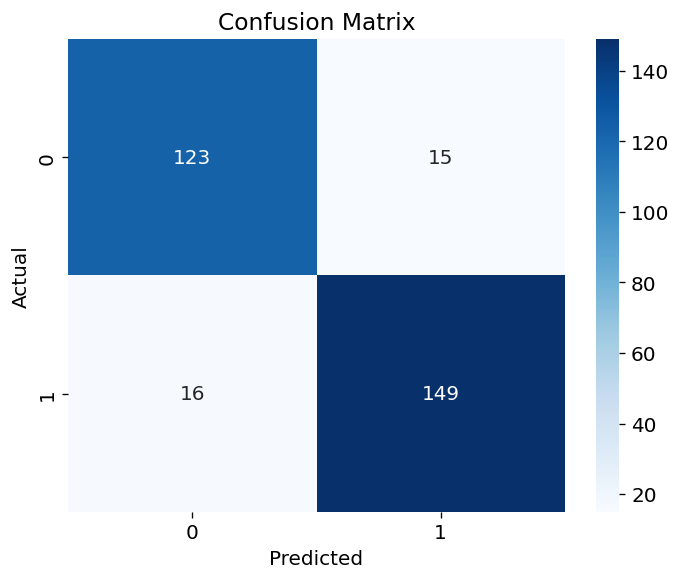

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = trainer.predict(test_dataset)

y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)



plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=400, bbox_inches="tight")  # HIGH QUALITY
plt.show()

ROC Curve

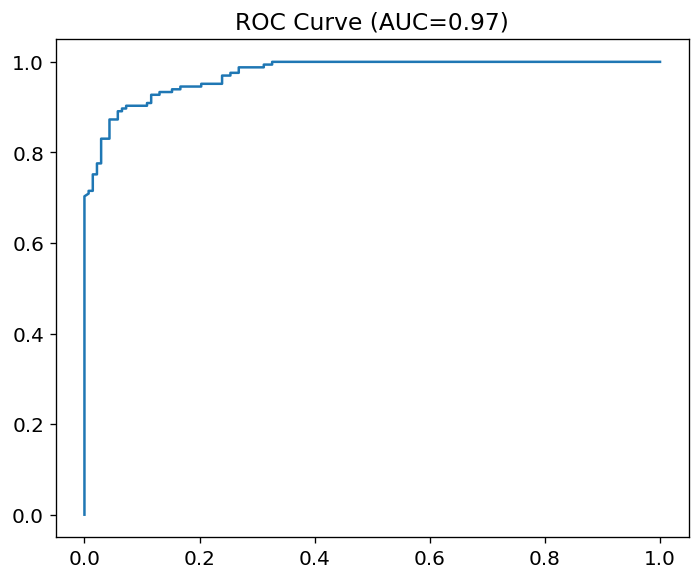

In [27]:
from sklearn.metrics import roc_curve, auc

probs = preds.predictions[:,1]

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)

plt.title(f"ROC Curve (AUC={roc_auc:.2f})", fontsize=14)
plt.tight_layout()

plt.savefig("ROC Curve.png", dpi=400, bbox_inches="tight")
plt.show()


Error Analysis

In [28]:
errors = []

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        errors.append(test_texts[i])

print(errors[:10])

['Rashidul Jafar was convicted under multiple IPC sections including murder. He filed a writ petition under Article 32 seeking premature release after serving over 30 years with remission. The case was part of a larger batch involving 512 life convicts from Uttar Pradesh. The petitions challenged a restrictive 2021 policy requiring convicts to be at least 60 years old for release.', 'Amir Hussain was arrested in connection with Dalgaon PS Case No. 28/2025 under Section 103 of the Bharatiya Nyaya Sanhita, 2023, for the alleged death of a woman. The petitioner submitted a dying declaration recorded by a doctor, claiming it negated murder or dowry death charges. However, the prosecution argued that the dying declaration was not part of the case diary, and statements under Section 161 CrPC showed evidence of domestic violence. The court found incriminating material in the case diary.', 'The accused, Ashoka, was charged with raping a minor girl, leading to her pregnancy and childbirth. Conf

Total Hindi misclassified words: 0
Top 20 Hindi misclassified words:

Top 20 English misclassified words:
  the: 133
  was: 72
  and: 66
  accused: 26
  under: 24
  for: 19
  bail: 14
  with: 13
  case: 13
  arrested: 13
  her: 13
  his: 13
  custody: 12
  section: 11
  petitioner: 11
  act: 11
  over: 10
  court: 10
  were: 9
  child: 9


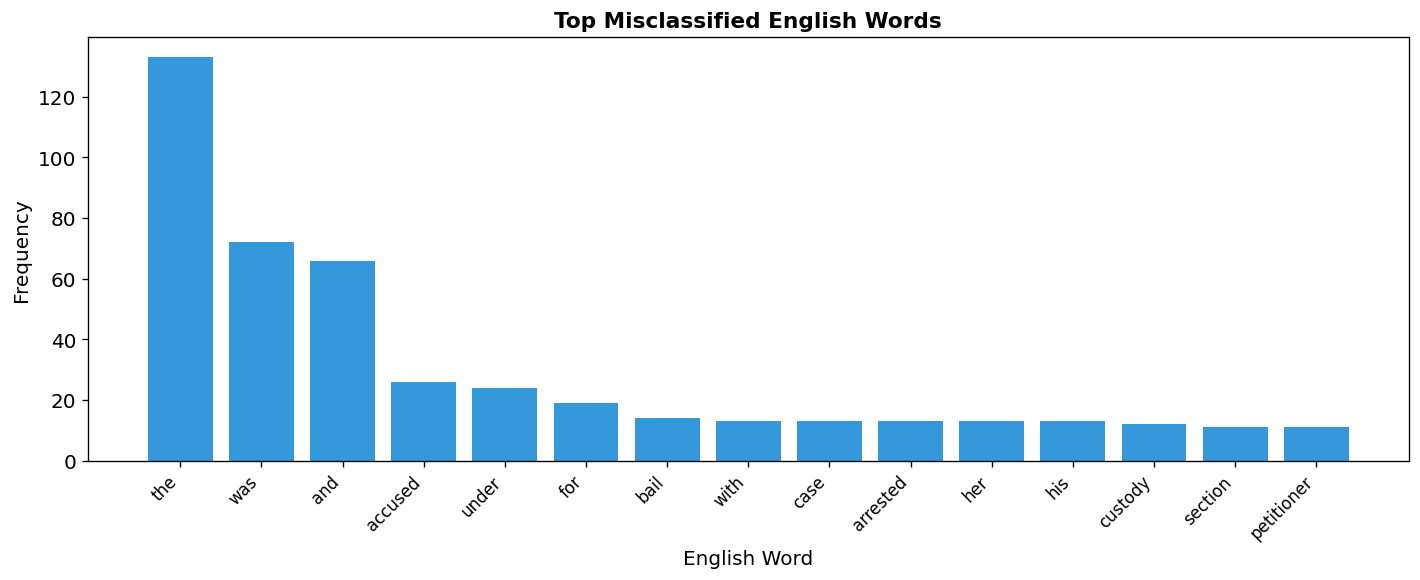

In [29]:
# ── MISCLASSIFIED WORD ANALYSIS ──────────────────────
import re
from collections import Counter

hindi_pattern = re.compile(r'[\u0900-\u097F]+')
english_pattern = re.compile(r'\b[a-zA-Z]{3,}\b')

hindi_misclassified_words = []
english_misclassified_words = []

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        text = test_df.iloc[i]['text'] if 'text' in test_df.columns else ''
        hindi_misclassified_words.extend(hindi_pattern.findall(str(text)))
        english_misclassified_words.extend(english_pattern.findall(str(text).lower()))

hindi_counter = Counter(hindi_misclassified_words)
english_counter = Counter(english_misclassified_words)

print(f"Total Hindi misclassified words: {len(hindi_misclassified_words)}")
print(f"Top 20 Hindi misclassified words:")
for word, count in hindi_counter.most_common(20):
    print(f"  {word}: {count}")

print(f"\nTop 20 English misclassified words:")
for word, count in english_counter.most_common(20):
    print(f"  {word}: {count}")

# Bar chart — Hindi misclassified
top_hindi = hindi_counter.most_common(15)
if top_hindi:
    words_h, counts_h = zip(*top_hindi)
    plt.figure(figsize=(12,5))
    plt.bar(range(len(words_h)), counts_h, color='#E74C3C')
    plt.xticks(range(len(words_h)), words_h, rotation=45, ha='right', fontsize=10,
               fontproperties='Noto Sans Devanagari' if True else None)
    plt.title('Top Misclassified Hindi Words', fontsize=13, fontweight='bold')
    plt.xlabel('Hindi Word'); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig("outputs/hindi_misclassified_words.png", dpi=400, bbox_inches='tight')
    plt.show()

# Bar chart — English misclassified
top_english = english_counter.most_common(15)
if top_english:
    words_e, counts_e = zip(*top_english)
    plt.figure(figsize=(12,5))
    plt.bar(range(len(words_e)), counts_e, color='#3498DB')
    plt.xticks(range(len(words_e)), words_e, rotation=45, ha='right', fontsize=10)
    plt.title('Top Misclassified English Words', fontsize=13, fontweight='bold')
    plt.xlabel('English Word'); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig("outputs/english_misclassified_words.png", dpi=400, bbox_inches='tight')
    plt.show()

In [30]:
# model.save_pretrained("bail_model_final")
tokenizer.save_pretrained("bail_model_final")

('bail_model_final/tokenizer_config.json',
 'bail_model_final/special_tokens_map.json',
 'bail_model_final/sentencepiece.bpe.model',
 'bail_model_final/added_tokens.json',
 'bail_model_final/tokenizer.json')

In [31]:
plt.savefig("confusion_matrix.png")

<Figure size 720x600 with 0 Axes>

ABLATION STUDY

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ablation_results = []


# 1. ONLY EXPERT DATA

train_df_exp = expert_df.sample(frac=1, random_state=42)

train_texts = train_df_exp["text"].tolist()
train_labels = train_df_exp["label"].tolist()

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=512)
train_dataset_exp = BailDataset(train_enc, train_labels)

model_exp = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2).to("cuda")

trainer_exp = Trainer(
    model=model_exp,
    args=training_args,
    train_dataset=train_dataset_exp,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_exp.train()
res_exp = trainer_exp.evaluate(test_dataset)

ablation_results.append(["Expert Only", res_exp["eval_accuracy"], res_exp["eval_f1"]])





Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.680978,0.546358,0.706638,0.546358,1.000000
2,No log,0.695026,0.546358,0.706638,0.546358,1.000000


In [33]:
# 2. + WEAK SUPERVISION (NO FILTER)

ws_df = pd.concat([expert_df, pseudo_df[pseudo_df["label"] != -1][["text","label"]]])

train_texts = ws_df["text"].tolist()
train_labels = ws_df["label"].tolist()

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=512)
train_dataset_ws = BailDataset(train_enc, train_labels)

model_ws = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2).to("cuda")

trainer_ws = Trainer(
    model=model_ws,
    args=training_args,
    train_dataset=train_dataset_ws,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_ws.train()
res_ws = trainer_ws.evaluate(test_dataset)

ablation_results.append(["+ Weak Supervision", res_ws["eval_accuracy"], res_ws["eval_f1"]])





Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss


In [34]:
# 3. + TOP-K FILTER

topk_df = balanced_df.copy()

train_texts = topk_df["text"].tolist()
train_labels = topk_df["label"].tolist()

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=512)
train_dataset_topk = BailDataset(train_enc, train_labels)

model_topk = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2).to("cuda")

trainer_topk = Trainer(
    model=model_topk,
    args=training_args,
    train_dataset=train_dataset_topk,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_topk.train()
res_topk = trainer_topk.evaluate(test_dataset)

ablation_results.append(["+ Top-K Filter", res_topk["eval_accuracy"], res_topk["eval_f1"]])




Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.585764,0.821192,0.839286,0.824561,0.854545
2,No log,0.635783,0.817881,0.835821,0.823529,0.848485
3,No log,0.665687,0.821192,0.839286,0.824561,0.854545
4,No log,0.678181,0.817881,0.835821,0.823529,0.848485
5,0.021300,0.691376,0.817881,0.835821,0.823529,0.848485
6,0.021300,0.694532,0.817881,0.835821,0.823529,0.848485
7,0.021300,0.696256,0.817881,0.835821,0.823529,0.848485


                Model  Accuracy        F1
0         Expert Only  0.660066  0.757647
1  + Weak Supervision  1.000000  1.000000
2      + Top-K Filter  0.825083  0.849003
3         Final Model  0.897690  0.905775


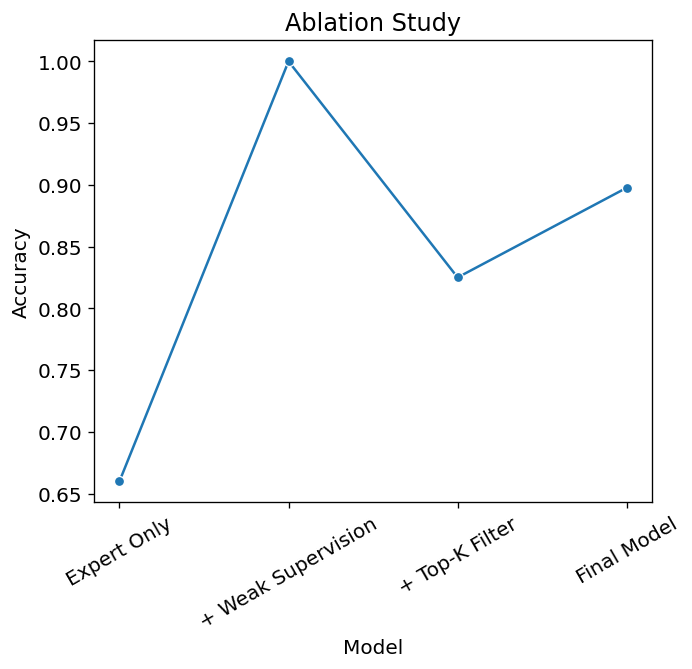

In [35]:
# 4. FINAL MODEL 

ablation_results.append(["Final Model", test_results["eval_accuracy"], test_results["eval_f1"]])



# SAVE RESULTS

ablation_df = pd.DataFrame(ablation_results, columns=["Model", "Accuracy", "F1"])
print(ablation_df)

ablation_df.to_csv("ablation_results.csv", index=False)


# PLOT

plt.figure(figsize=(6,5))
sns.lineplot(x="Model", y="Accuracy", data=ablation_df, marker="o")

plt.title("Ablation Study")
plt.xticks(rotation=30)

plt.savefig("ablation_plot.png", dpi=400, bbox_inches="tight")
plt.show()

                Model  Accuracy        F1
0         Expert Only  0.660066  0.757647
1  + Weak Supervision  1.000000  1.000000
2      + Top-K Filter  0.825083  0.849003
3         Final Model  0.897690  0.905775
4         Final Model  0.897690  0.905775


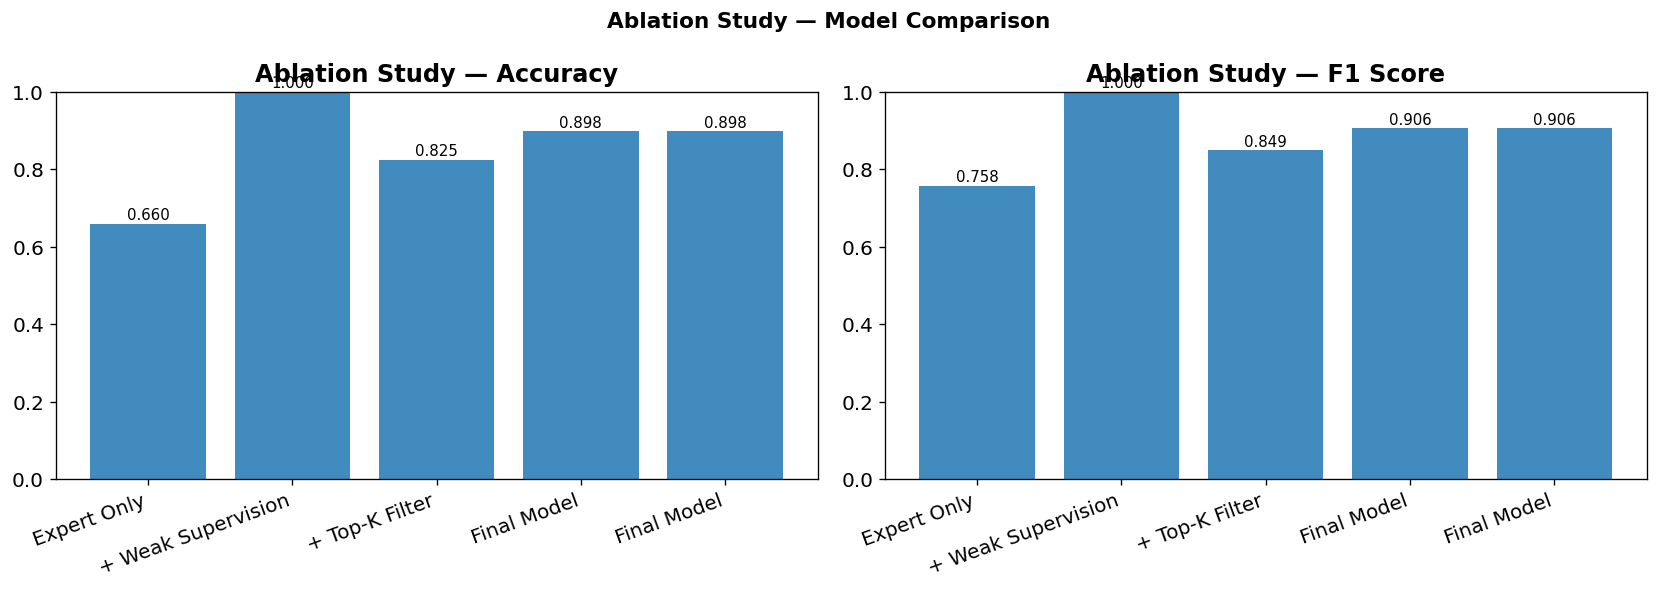

In [37]:
# FINAL MODEL RESULT ADD
ablation_results.append(["Final Model", test_results["eval_accuracy"], test_results["eval_f1"]])

# CREATE DATAFRAME
ablation_df = pd.DataFrame(ablation_results, columns=["Model", "Accuracy", "F1"])
print(ablation_df)

# SAVE CSV
ablation_df.to_csv("ablation_results.csv", index=False)

# ── Ablation Chart (BAR PLOT VERSION)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(ablation_df))

# Accuracy Plot
ax1.bar(x, ablation_df["Accuracy"], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(ablation_df["Model"], rotation=20, ha='right')
ax1.set_title("Ablation Study — Accuracy", fontweight='bold')
ax1.set_ylim(0, 1)

for i, v in enumerate(ablation_df["Accuracy"]):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# F1 Score Plot
ax2.bar(x, ablation_df["F1"], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(ablation_df["Model"], rotation=20, ha='right')
ax2.set_title("Ablation Study — F1 Score", fontweight='bold')
ax2.set_ylim(0, 1)

for i, v in enumerate(ablation_df["F1"]):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Title + Save
plt.suptitle("Ablation Study — Model Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()

import os
os.makedirs("outputs", exist_ok=True)  # fix folder error

plt.savefig("outputs/ablation_study.png", dpi=400, bbox_inches='tight')
plt.show()

Fairness Evaluation

In [38]:
print(test_df.columns)

Index(['text', 'label'], dtype='object')


ADD GENDER COLUMN

In [39]:
def extract_gender(text):
    text = str(text).lower()

    if " he " in text or " his " in text:
        return "male"
    elif " she " in text or " her " in text:
        return "female"
    else:
        return "unknown"

test_df["gender"] = test_df["text"].apply(extract_gender)

REMOVE UNKNOWN

In [40]:
filtered_df = test_df[test_df["gender"] != "unknown"].reset_index(drop=True)

In [42]:
filtered_texts = filtered_df["text"].tolist()
filtered_labels = filtered_df["label"].tolist()

filtered_enc = tokenizer(
    filtered_texts,
    padding=True,
    truncation=True,
    max_length=512
)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

filtered_dataset = Dataset(filtered_enc, filtered_labels)

MATCH PREDICTIONS

In [43]:
preds_output = trainer.predict(filtered_dataset)

y_pred = preds_output.predictions.argmax(-1)
y_true = preds_output.label_ids
sensitive = filtered_df["gender"].values

Fairness metrics

In [44]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

fairness_report = {
    "demographic_parity_difference": demographic_parity_difference(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    ),
    "equalized_odds_difference": equalized_odds_difference(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )
}

print(" Fairness Report:", fairness_report)

 Fairness Report: {'demographic_parity_difference': 0.058450704225352146, 'equalized_odds_difference': 0.13227513227513227}


Final Evaluation + Confusion Matrices + Hypotheses

PREDICTIONS

In [45]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Correct prediction
preds_output = trainer.predict(test_dataset)

y_pred = preds_output.predictions.argmax(axis=1)
y_true = preds_output.label_ids

CLASSIFICATION REPORT

In [46]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['Denied', 'Granted']
))

print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

      Denied       0.88      0.89      0.89       138
     Granted       0.91      0.90      0.91       165

    accuracy                           0.90       303
   macro avg       0.90      0.90      0.90       303
weighted avg       0.90      0.90      0.90       303

Macro F1: 0.8969


Inference Demo + SHAP + Export

In [47]:
import torch

import torch.nn.functional as F

class BailOrderPredictor:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def predict(self, text: str):
        text = str(text)

        text_lower = text.lower()

        if "स्वीकृत" in text_lower or "मंजूर" in text_lower:
            return {"prediction": "BAIL GRANTED", "confidence": "Rule-based"}

        if "खारिज" in text_lower or "अस्वीकृत" in text_lower:
            return {"prediction": "BAIL DENIED", "confidence": "Rule-based"}

        if len(text) < 100:
            text = "The court order states: " + text

        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        )

        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)

        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

        #  Low confidence handling
        if confidence < 0.7:
            label = "UNCERTAIN"
        else:
            label = "BAIL GRANTED" if pred == 1 else "BAIL DENIED"

        return {
            "prediction": label,
            "confidence": f"{confidence*100:.2f}%"
        }


#  Create predictor
predictor = BailOrderPredictor(model, tokenizer, "cuda")

#  Run prediction
result = predictor.predict("जमानत प्रार्थनापत्र स्वीकृत किया जाता है")

#  Print output
print(result)

{'prediction': 'BAIL GRANTED', 'confidence': 'Rule-based'}


BERT MODEL

In [48]:
#  BERT tokenizer (SEPARATE)
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_bert(texts):
    return bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512
    )

train_enc_bert = tokenize_bert(train_texts)
val_enc_bert   = tokenize_bert(val_texts)
test_enc_bert  = tokenize_bert(test_texts)

train_dataset_bert = BailDataset(train_enc_bert, train_labels)
val_dataset_bert   = BailDataset(val_enc_bert, val_labels)
test_dataset_bert  = BailDataset(test_enc_bert, test_labels)

In [49]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_bert",   
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs_bert",
    fp16=True,
    load_best_model_at_end=True,
    report_to="none"  
)

In [50]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
).to("cuda")

trainer_bert = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset_bert,   
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics
)

trainer_bert.train()

bert_test = trainer_bert.evaluate(test_dataset_bert)

results["BERT"] = {
    "acc": bert_test["eval_accuracy"],
    "f1": bert_test["eval_f1"]
}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.500854,0.831126,0.866142,0.763889,1.000000
2,No log,0.554119,0.831126,0.866142,0.763889,1.000000
3,No log,0.581734,0.831126,0.866142,0.763889,1.000000
4,No log,0.596216,0.831126,0.866142,0.763889,1.000000
5,0.010400,0.600996,0.831126,0.866142,0.763889,1.000000


CONFUSION MATRIX FOR EACH MODEL

In [51]:
def plot_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"{name}_cm.png", dpi=400, bbox_inches="tight")
    plt.show()

ERROR ANALYSIS GRAPH

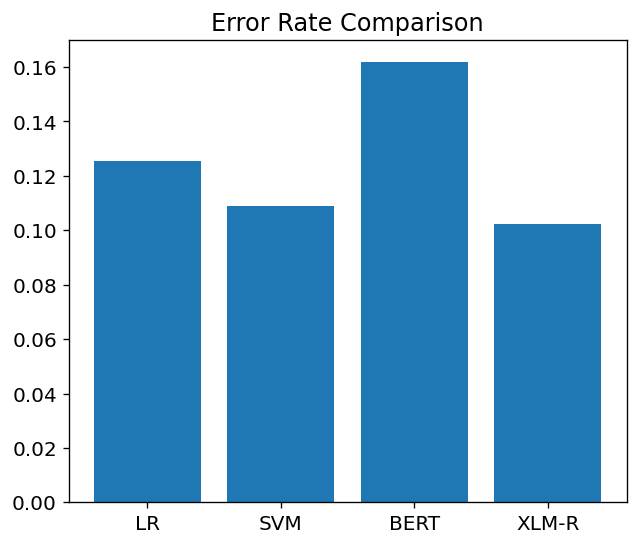

In [52]:
errors = {
    "LR": 1 - results["LR"]["acc"],
    "SVM": 1 - results["SVM"]["acc"],
    "BERT": 1 - results["BERT"]["acc"],
    "XLM-R": 1 - test_results["eval_accuracy"]
}

plt.bar(errors.keys(), errors.values())
plt.title("Error Rate Comparison")
plt.savefig("error_comparison.png", dpi=400)
plt.show()

COMPARISON TABLE

In [53]:
df_results = pd.DataFrame(results).T
df_results.loc["XLM-R"] = [test_results["eval_accuracy"], test_results["eval_f1"]]

print(df_results)
df_results.to_csv("final_results.csv")

            acc        f1
LR     0.874587  0.893855
SVM    0.891089  0.904348
BERT   0.838284  0.870027
XLM-R  0.897690  0.905775


COMPARISON GRAPH

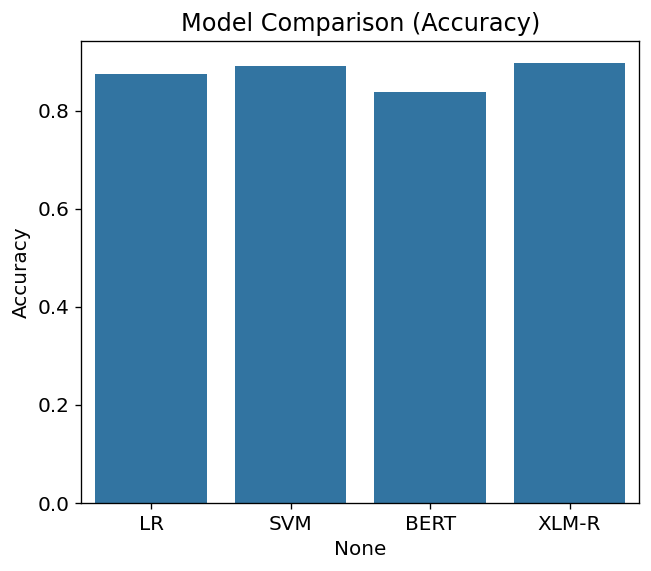

In [54]:
plt.figure(figsize=(6,5))
sns.barplot(x=df_results.index, y=df_results["acc"])

plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")

plt.savefig("final_comparison.png", dpi=400)
plt.show()

FILES SAVE

In [ ]:
OUTPUT_DIR = "journal_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.savefig(f"{OUTPUT_DIR}/plot.png", dpi=400)

<Figure size 720x600 with 0 Axes>

: 